Le prétraitement des données

In [2]:
import pandas as pd

df = pd.read_csv("../data/cache_filtre.csv")
print("Avant nettoyage :", df.shape)

mask_corrompu = df['label'].astype(str).str.lower() == 'label'
print("Lignes corrompues trouvées :", mask_corrompu.sum())

df_propre = df[~mask_corrompu].reset_index(drop=True)
df_propre.to_csv("../data/cache_filtre.csv", index=False)
print("Après nettoyage :", df_propre.shape)

Avant nettoyage : (900000, 47)
Lignes corrompues trouvées : 0
Après nettoyage : (900000, 47)


 Les 5 attaques  (DDoS, DoS, Mirai, Recon, Spoofing) et  le trafic sain (BenignTraffic)

In [ ]:
import pandas as pd
import numpy as np
import os
import glob
from collections import defaultdict


FAMILLES_CIBLES = ['DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing']
LABEL_BENIN = 'BenignTraffic'
MAPPING_EXPLICITE = {
    'DNS_Spoofing': 'Spoofing', 'MITM-ArpSpoofing': 'Spoofing'
}
def mapper_famille(label):
    if label == LABEL_BENIN: return LABEL_BENIN
    if label in MAPPING_EXPLICITE: return MAPPING_EXPLICITE[label]
    for famille in FAMILLES_CIBLES:
        if label.startswith(famille): return famille
    return None
DATASET_PATH = "../data/CICIoT2023"
CACHE_PATH = "../data/cache_filtre.csv"
fichiers = sorted(glob.glob(os.path.join(DATASET_PATH, "*.csv")))
compteur = defaultdict(int)
max_par_famille = 150000
if os.path.exists(CACHE_PATH):
    os.remove(CACHE_PATH)
premiere_ecriture = True
for i, f in enumerate(fichiers, 1):
    for chunk in pd.read_csv(f, chunksize=50000):
        chunk['famille'] = chunk['label'].apply(mapper_famille)
        chunk = chunk[chunk['famille'].notna()]

        chunks_filtres = []
        for fam in chunk['famille'].unique():
            reste = max_par_famille - compteur[fam]
            if reste > 0:
                sous_chunk = chunk[chunk['famille'] == fam].head(reste)
                compteur[fam] += len(sous_chunk)
                chunks_filtres.append(sous_chunk)

        if chunks_filtres:
            chunk_final = pd.concat(chunks_filtres).drop(columns=['famille'])
            chunk_final.to_csv(CACHE_PATH, mode='a', header=premiere_ecriture, index=False)
            premiere_ecriture = False
    print(f"Processed file {i}/{len(fichiers)}")

Processed file 1/169
Processed file 2/169
Processed file 3/169
Processed file 4/169
Processed file 5/169
Processed file 6/169
Processed file 7/169
Processed file 8/169
Processed file 9/169
Processed file 10/169
Processed file 11/169
Processed file 12/169
Processed file 13/169
Processed file 14/169
Processed file 15/169
Processed file 16/169
Processed file 17/169
Processed file 18/169
Processed file 19/169
Processed file 20/169
Processed file 21/169
Processed file 22/169
Processed file 23/169
Processed file 24/169
Processed file 25/169
Processed file 26/169
Processed file 27/169
Processed file 28/169
Processed file 29/169
Processed file 30/169
Processed file 31/169
Processed file 32/169
Processed file 33/169
Processed file 34/169
Processed file 35/169
Processed file 36/169
Processed file 37/169
Processed file 38/169
Processed file 39/169
Processed file 40/169
Processed file 41/169
Processed file 42/169
Processed file 43/169
Processed file 44/169
Processed file 45/169
Processed file 46/1

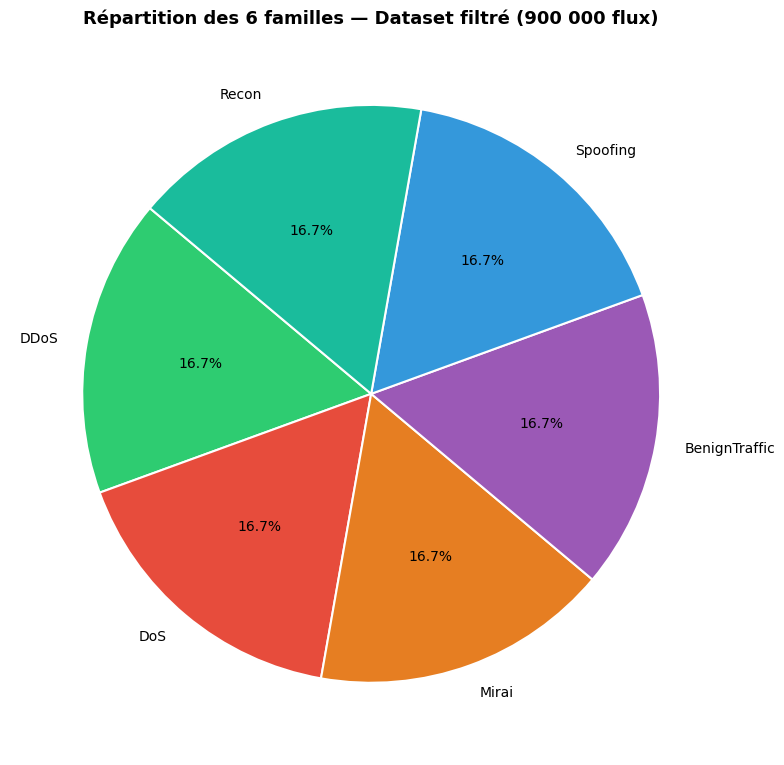

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/cache_filtre.csv')
counts = df['label'].value_counts()

couleurs = ['#2ecc71','#e74c3c','#e67e22','#9b59b6','#3498db','#1abc9c']
plt.figure(figsize=(8, 8))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
        startangle=140, colors=couleurs,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Répartition des 6 familles — Dataset filtré (900 000 flux)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/repartition_classes_pie.png', dpi=150)
plt.show()